## tl;dr

- RevFactor has **351 active, syncing PriceLabs listings across 162 raw city/state labels**. A coordinate-based sensitivity check produces **119 clusters at 15 miles** and **96 at 30 miles**, so the economic unit should be a governed market cluster—not a raw city string and not automatically one license per property.
- PredictHQ's **$600/property/year sticker price implies $210,600/year** before volume discount, equal to **16.7% of the stated $300/listing/month RevFactor fee base**. Raw small-city pricing would start at $405,000/year before any major-city uplift.
- The five-market, 90-day sample confirms strong normalization and long-lead `first_seen` evidence, but **Surge returned zero dates for Park City and the Smokies** even while the Events feed contained material destination events. The product must use raw events plus change detection, not Surge alone.
- Recommendation: build a source-agnostic signal-to-action layer first, use the trial as benchmark data, and defer a broad PredictHQ purchase until a controlled pilot measures incremental lead time, precision, and captured revenue.

## Context & Methods

This notebook supports the decision: **buy PredictHQ broadly, build internally, or use a hybrid** for RevFactor's market-event monitoring.

Sources reviewed on August 21, 2026:

- Live PriceLabs `/v1/listings` response for active, syncing, non-hidden listings. Only aggregate counts and market labels are retained here; listing names, IDs, notes, and credentials are excluded.
- Live PredictHQ Events, Suggested Radius, and Demand Surge API responses for five markets over August 21–November 19, 2026.
- The user-supplied PredictHQ discovery-call summary for commercial assumptions.
- PredictHQ, Ticketmaster, National Weather Service, and GDELT documentation for source capabilities.

### Key Assumptions

- The commercial prices are discovery-call figures, not a binding quote; the volume discount is unknown.
- Geographic clusters are a sensitivity analysis using straight-line distance, not final operating markets or vendor billing units.
- `local_rank >= 50` is intentionally shown as a naive threshold to test noise; it is not the recommended production rule.
- No causal revenue uplift is claimed. The NFL Draft miss supplies the business problem, but booking and counterfactual pricing data were not available for loss sizing.

## Data

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidates = [
    Path("case-study-input.json"),
    Path("docs/analysis/event-intelligence/case-study-input.json"),
]
input_path = next(path for path in candidates if path.exists())
data = json.loads(input_path.read_text())

portfolio = data["portfolio"]
density = pd.DataFrame(portfolio["city_density_buckets"])
markets = pd.DataFrame(data["case_study_markets"])
commercial = data["commercial_assumptions"]

data["as_of"], data["analysis_window"]

Matplotlib is building the font cache; this may take a moment.


('2026-08-21T18:00:00Z',
 {'from': '2026-08-21', 'to': '2026-11-19', 'days': 90})

### Validate aggregate inputs

In [2]:
assert portfolio["listings"] == portfolio["unique_listing_ids"]
assert portfolio["listings"] == portfolio["listings_with_coordinates"]
assert density["listings"].sum() == portfolio["listings"]
assert density["cities"].sum() == portfolio["raw_city_state_pairs"]
assert len(markets) == 5
assert markets["market"].is_unique
assert (markets["local_rank_50_plus_count"] <= markets["event_count"]).all()

pd.DataFrame(
    [
        {"check": "Unique listing IDs", "value": portfolio["unique_listing_ids"], "status": "pass"},
        {"check": "Listings with coordinates", "value": portfolio["listings_with_coordinates"], "status": "pass"},
        {"check": "Missing city labels", "value": portfolio["missing_city"], "status": "pass"},
        {"check": "Missing state labels", "value": portfolio["missing_state"], "status": "caveat"},
    ]
)

,check,value,status
0,Unique listing IDs,351,pass
1,Listings with coordinates,351,pass
2,Missing city labels,0,pass
3,Missing state labels,3,caveat


## Results

### The portfolio is geographically dispersed

In [3]:
density["listing_share"] = density["listings"] / portfolio["listings"]
low_density_listings = density.loc[density["bucket"].isin(["1 listing", "2–4 listings"]), "listings"].sum()
low_density_share = low_density_listings / portfolio["listings"]

density.assign(listing_share=density["listing_share"].map(lambda value: f"{value:.1%}"))

,bucket,cities,listings,listing_share
0,1 listing,100,100,28.5%
1,2–4 listings,48,127,36.2%
2,5–9 listings,11,68,19.4%
3,10+ listings,3,56,16.0%


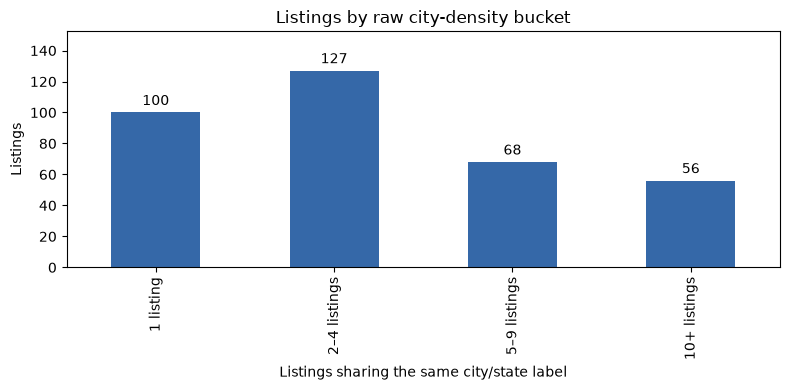

In [4]:
ax = density.plot.bar(
    x="bucket",
    y="listings",
    legend=False,
    color="#3568a8",
    figsize=(8, 4),
)
ax.set_title("Listings by raw city-density bucket")
ax.set_xlabel("Listings sharing the same city/state label")
ax.set_ylabel("Listings")
ax.set_ylim(0, max(density["listings"]) * 1.2)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

### Commercial sensitivity favors a benchmark-first hybrid

In [5]:
annual_fee_base = portfolio["listings"] * commercial["revfactor_monthly_fee_per_listing_usd"] * 12
property_sticker = portfolio["listings"] * commercial["predicthq_property_sticker_annual_usd"]
raw_small_city_floor = portfolio["raw_city_state_pairs"] * commercial["predicthq_small_city_annual_usd"]
pilot_listings = int(markets["portfolio_listings"].sum())
pilot_property_sticker = pilot_listings * commercial["predicthq_property_sticker_annual_usd"]

commercial_summary = pd.DataFrame(
    [
        {"scenario": "Full portfolio — per-property sticker", "annual_cost_usd": property_sticker, "share_of_fee_base": property_sticker / annual_fee_base},
        {"scenario": "Full portfolio — raw small-city floor", "annual_cost_usd": raw_small_city_floor, "share_of_fee_base": raw_small_city_floor / annual_fee_base},
        {"scenario": "Five-market case study — per-property sticker", "annual_cost_usd": pilot_property_sticker, "share_of_fee_base": pilot_property_sticker / annual_fee_base},
    ]
)
commercial_summary.assign(
    annual_cost_usd=commercial_summary["annual_cost_usd"].map(lambda value: f"${value:,.0f}"),
    share_of_fee_base=commercial_summary["share_of_fee_base"].map(lambda value: f"{value:.1%}"),
)

,scenario,annual_cost_usd,share_of_fee_base
0,Full portfolio — per-property sticker,"$210,600",16.7%
1,Full portfolio — raw small-city floor,"$405,000",32.1%
2,Five-market case study — per-property sticker,"$47,400",3.8%


### PredictHQ is useful evidence, but a naive rank rule is too noisy

In [6]:
markets["local_rank_50_share"] = markets["local_rank_50_plus_count"] / markets["event_count"]
markets["example_lead_days"] = (
    pd.to_datetime(markets["example_event"].map(lambda _: data["analysis_window"]["from"]))
    - pd.to_datetime(markets["example_first_seen"])
).dt.days

markets[[
    "market",
    "portfolio_listings",
    "suggested_radius_miles",
    "event_count",
    "local_rank_50_plus_count",
    "local_rank_50_share",
    "surge_count",
    "example_event",
    "example_first_seen",
    "example_lead_days",
]].assign(local_rank_50_share=markets["local_rank_50_share"].map(lambda value: f"{value:.1%}"))

,market,portfolio_listings,suggested_radius_miles,event_count,local_rank_50_plus_count,local_rank_50_share,surge_count,example_event,example_first_seen,example_lead_days
0,"Washington, DC",3,2.95,2407,996,41.4%,3,Army Ten-Miler,2025-05-18,460
1,"Tucson, AZ",8,4.62,602,555,92.2%,2,Tucson Comic Con,2025-11-30,264
2,"Myrtle Beach, SC",18,7.33,276,267,96.7%,2,Dickens Christmas Show & Festivals,2025-02-16,551
3,"Park City, UT",3,7.97,144,143,99.3%,0,ProcessTechnologyXchange,2025-11-18,276
4,"Gatlinburg / Smokies, TN",47,7.87,145,137,94.5%,0,Dollywood Harvest Festival & Great Pumpkin Lum...,2026-07-20,32


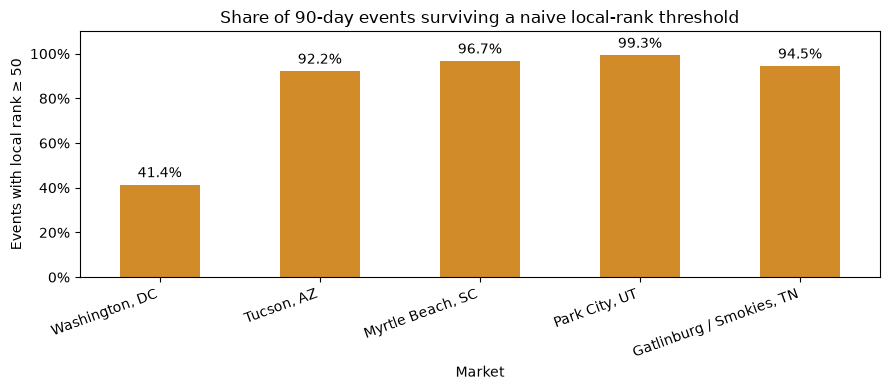

In [7]:
ax = markets.plot.bar(
    x="market",
    y="local_rank_50_share",
    legend=False,
    color="#d18b28",
    figsize=(9, 4),
)
ax.set_title("Share of 90-day events surviving a naive local-rank threshold")
ax.set_xlabel("Market")
ax.set_ylabel("Events with local rank ≥ 50")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in markets["local_rank_50_share"]], padding=3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Data quality is sufficient for a pilot, not for automatic market assignment

In [8]:
pd.DataFrame(portfolio["known_metadata_issues"])

,severity,issue,example,impact
0,medium,At least one city/state label conflicts with i...,A Sevierville coordinate in Tennessee is label...,Raw city/state counts should not define billin...
1,medium,Country labels are not normalized,United States and United States of America are...,Source routing and geographic coverage checks ...


## Takeaways

1. **Do not buy full-portfolio coverage yet.** The sticker economics are material and the volume discount is unknown.
2. **Do not build a PredictHQ clone.** Build the RevFactor-specific layer that vendors do not supply: early announcement monitoring, source reconciliation, booking-vulnerability checks, human review, and an audit trail into Adjustments/Revenue Manager.
3. **Use PredictHQ as one replaceable source.** Its normalized events, suggested radii, attendance, change timestamps, and accommodation impact patterns are useful; its Demand Surge endpoint is not sufficient for destination markets.
4. **Run a controlled five-market benchmark.** Measure alert precision, verified lead-time advantage over PriceLabs, recommendation acceptance, time-to-action, and revenue-at-risk/captured before committing to a broad license.
5. **Normalize the market registry first.** Use listing coordinates plus reviewed clusters and country codes. Raw city/state strings contain at least one contradiction and duplicate country naming.